# Milestone 2 Notebook: Machine Learning Analysis

This notebook documents the **Second milestone** of the Faker project for DSA210.
It focuses on supervised machine learning models built on the processed post-patch dataset.


## Objective

The machine learning stage asks whether post-patch outcomes can be predicted from:

- player identity
- champion identity and broad champion style
- pre-patch performance averages
- champion familiarity
- short historical rolling averages

Two binary classification tasks are studied:

1. **Post-patch stability**: whether a post-patch match stays within one pre-patch standard deviation of the player's pre-patch average.
2. **High-performance post-patch match**: whether a post-patch match is at or above the sample median performance index.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "processed").exists():
            return path
    raise FileNotFoundError("Could not locate project root with data/processed directory.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"

ml_df = pd.read_csv(DATA_DIR / "processed" / "post_patch_ml_dataset.csv", parse_dates=["date", "patch_date"])
comparison = pd.read_csv(DATA_DIR / "processed" / "ml_model_comparison.csv")
holdout = pd.read_csv(DATA_DIR / "processed" / "ml_holdout_results.csv")
importance = pd.read_csv(DATA_DIR / "processed" / "ml_feature_importance.csv")
preds = pd.read_csv(DATA_DIR / "processed" / "ml_crossval_predictions.csv", parse_dates=["date"])

print("ML rows:", len(ml_df))
print("Targets:", ", ".join(sorted(comparison["target_label"].unique())))
print("Models compared:", ", ".join(sorted(comparison["model"].unique())))


ML rows: 282
Targets: High-performance post-patch match, Post-patch stability
Models compared: logistic_regression, random_forest


## ML dataset overview


In [2]:
overview = pd.DataFrame({
    "Metric": [
        "Post-patch rows",
        "Players",
        "Patch windows",
        "Stable match positive rate",
        "High-performance positive rate"
    ],
    "Value": [
        len(ml_df),
        ", ".join(sorted(ml_df["player_name"].unique())),
        ", ".join(sorted(ml_df["patch"].astype(str).unique())),
        round(ml_df["stable_match"].mean(), 3),
        round(ml_df["high_performance_match"].mean(), 3),
    ]
})
display(overview)


,Metric,Value
0,Post-patch rows,282
1,Players,"Bdd, Caps, Chovy, Faker, ShowMaker, knight"
2,Patch windows,"14.13, 14.16, 14.5"
3,Stable match positive rate,0.557
4,High-performance positive rate,0.5


## Post-patch ML data preview


In [3]:
cols = [
    "date", "patch", "player_name", "champion_name", "primary_tag",
    "pre_perf_mean_window", "pre_diversity_entropy_window",
    "new_champion_for_player_patch", "stable_match", "high_performance_match"
]
display(ml_df[cols].head(12))


,date,patch,player_name,champion_name,primary_tag,pre_perf_mean_window,pre_diversity_entropy_window,new_champion_for_player_patch,stable_match,high_performance_match
0,2024-03-06 11:04:04.071462,14.5,Chovy,Taliyah,Mage,0.438608,1.947339,1,1,1
1,2024-03-06 11:55:10.627304,14.5,Chovy,Ahri,Mage,0.438608,1.947339,1,1,1
2,2024-03-07 07:59:24.589000,14.5,Faker,Taliyah,Mage,0.307882,2.345852,0,0,0
3,2024-03-07 08:49:36.125000,14.5,Faker,Taliyah,Mage,0.307882,2.345852,0,0,1
4,2024-03-07 09:55:37.252007,14.5,Bdd,Orianna,Mage,-0.450399,2.103910,0,0,1
5,2024-03-07 10:58:58.437908,14.5,Bdd,Orianna,Mage,-0.450399,2.103910,0,1,0
6,2024-03-08 09:12:48.643000,14.5,knight,Ahri,Mage,-0.327767,2.732159,0,0,1
7,2024-03-08 09:50:31.639459,14.5,ShowMaker,Taliyah,Mage,0.016400,1.295738,1,1,0
8,2024-03-08 09:59:21.971296,14.5,knight,Karma,Mage,-0.327767,2.732159,0,0,1
9,2024-03-08 10:54:40.765964,14.5,ShowMaker,Aurelion Sol,Mage,0.016400,1.295738,1,0,1


## Model comparison

Two models were compared:

- **Logistic regression**
- **Random forest**

Both were evaluated with **5-fold stratified cross-validation**.


In [4]:
display(comparison.round(4))


,target,target_label,model,n_samples,positive_rate,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std
0,stable_match,Post-patch stability,random_forest,282,0.5567,0.6240,0.0748,0.6124,0.0780,0.6790,0.0590,0.6394,0.0453
1,stable_match,Post-patch stability,logistic_regression,282,0.5567,0.5747,0.0759,0.5717,0.0699,0.6030,0.1005,0.6228,0.0530
2,high_performance_match,High-performance post-patch match,logistic_regression,282,0.5000,0.6810,0.0569,0.6808,0.0564,0.6679,0.0519,0.7042,0.0271
3,high_performance_match,High-performance post-patch match,random_forest,282,0.5000,0.6380,0.0389,0.6374,0.0383,0.6342,0.0432,0.6740,0.0520


### Stability task: model comparison


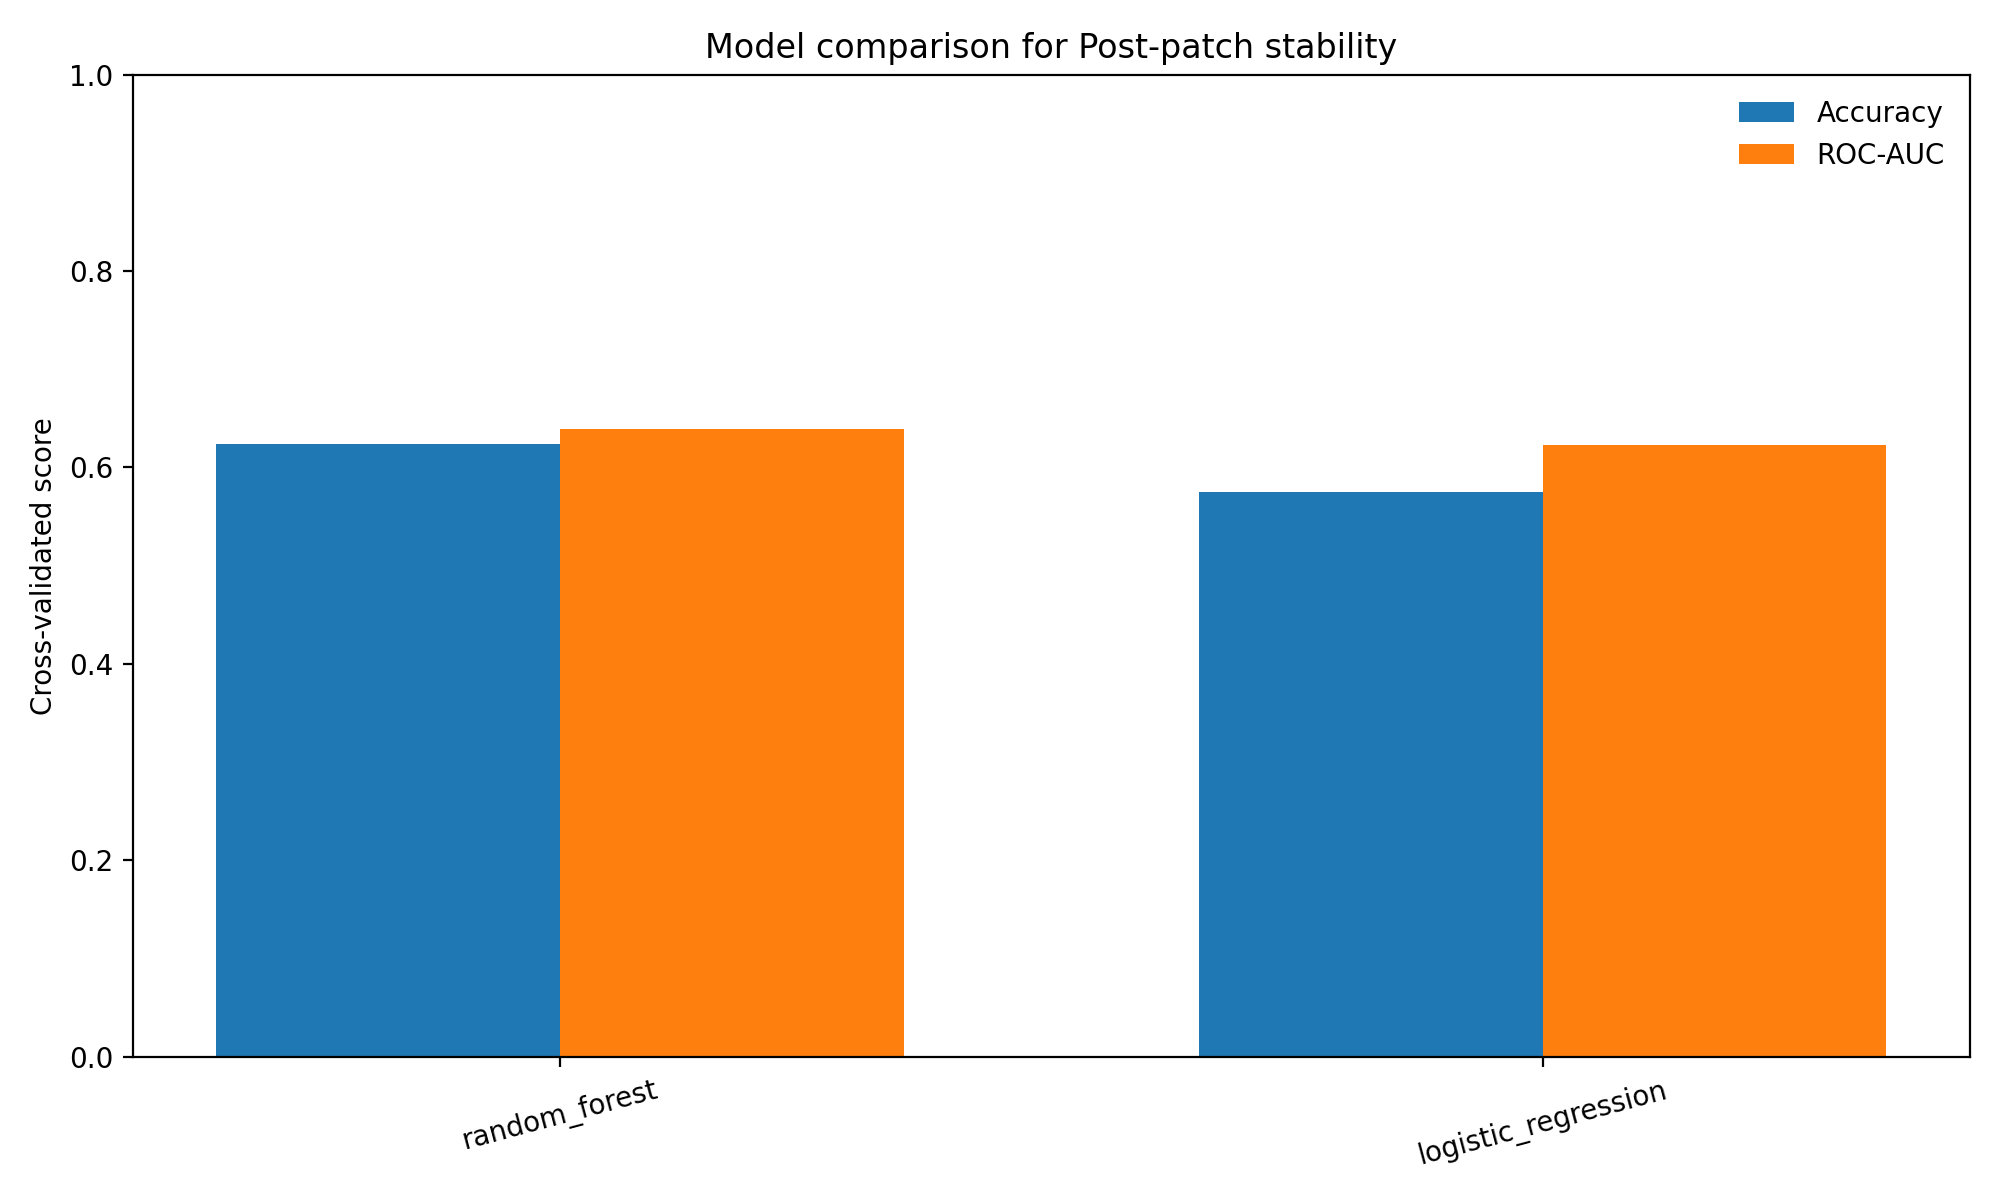

In [5]:
display(Image(filename=str(FIG_DIR / "ml_model_comparison_stability.png")))


### High-performance task: model comparison


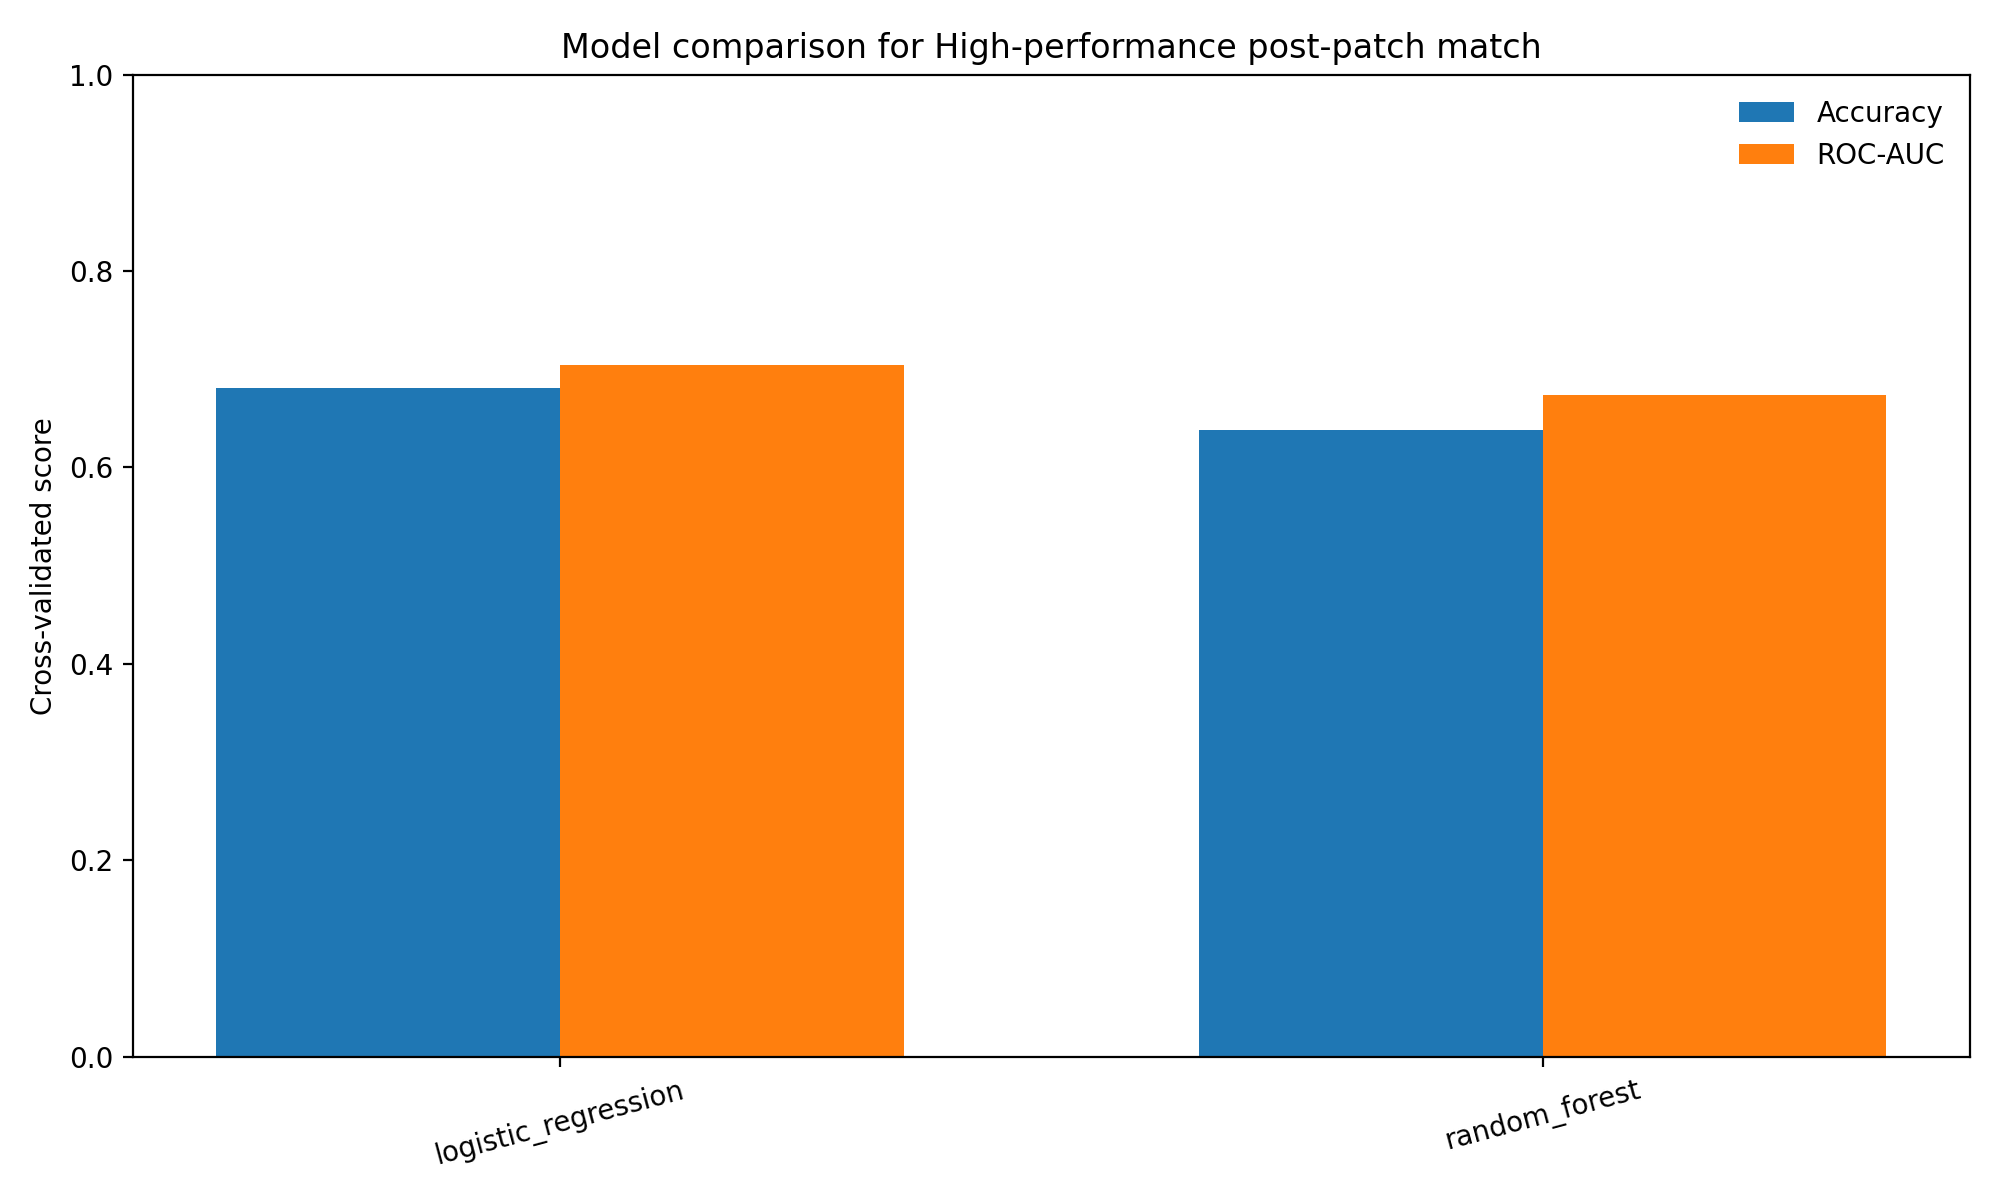

In [6]:
display(Image(filename=str(FIG_DIR / "ml_model_comparison_high_perf.png")))


**Interpretation:** the best cross-validated model is not the same for both targets. This suggests that different aspects of post-patch behavior may depend on different patterns in the data.


## Out-of-fold diagnostic plots


### Stability task diagnostics


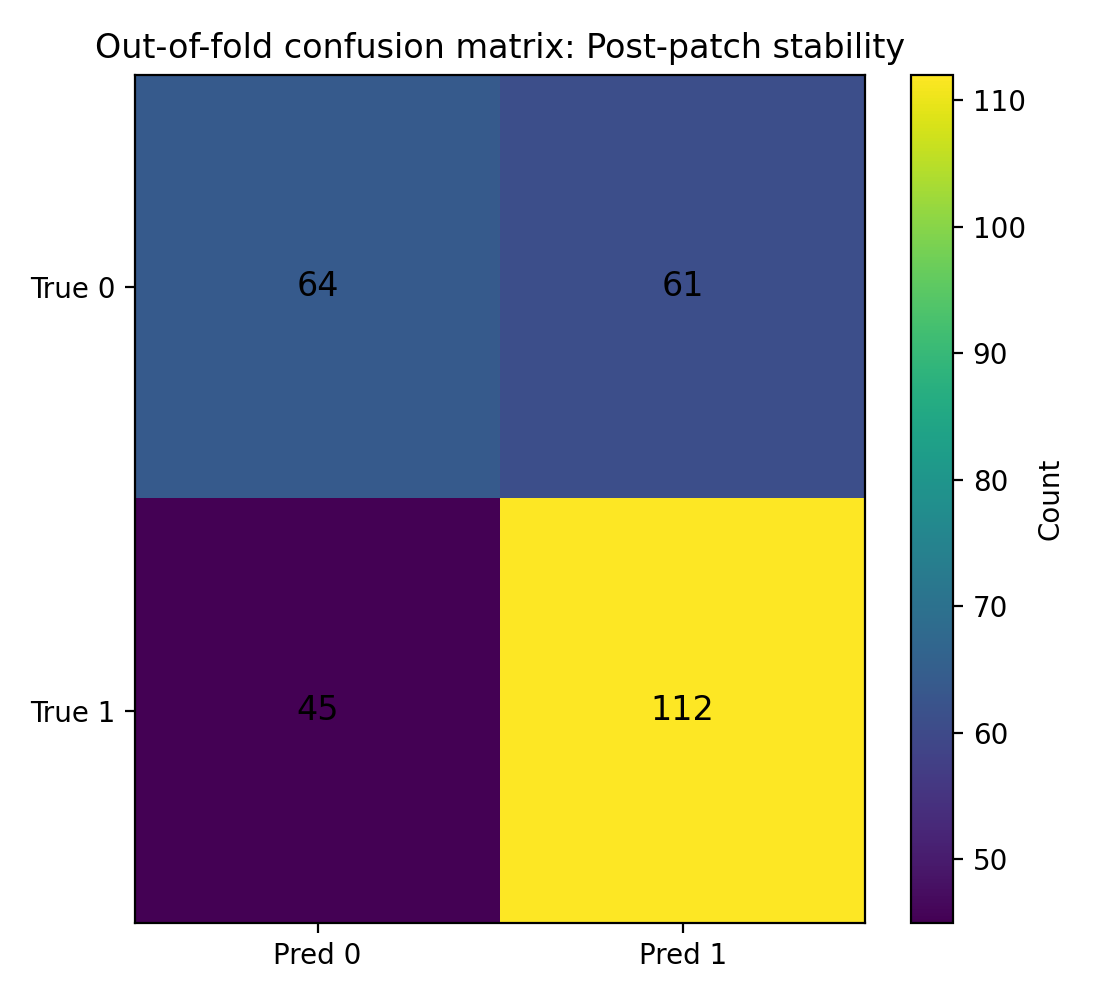

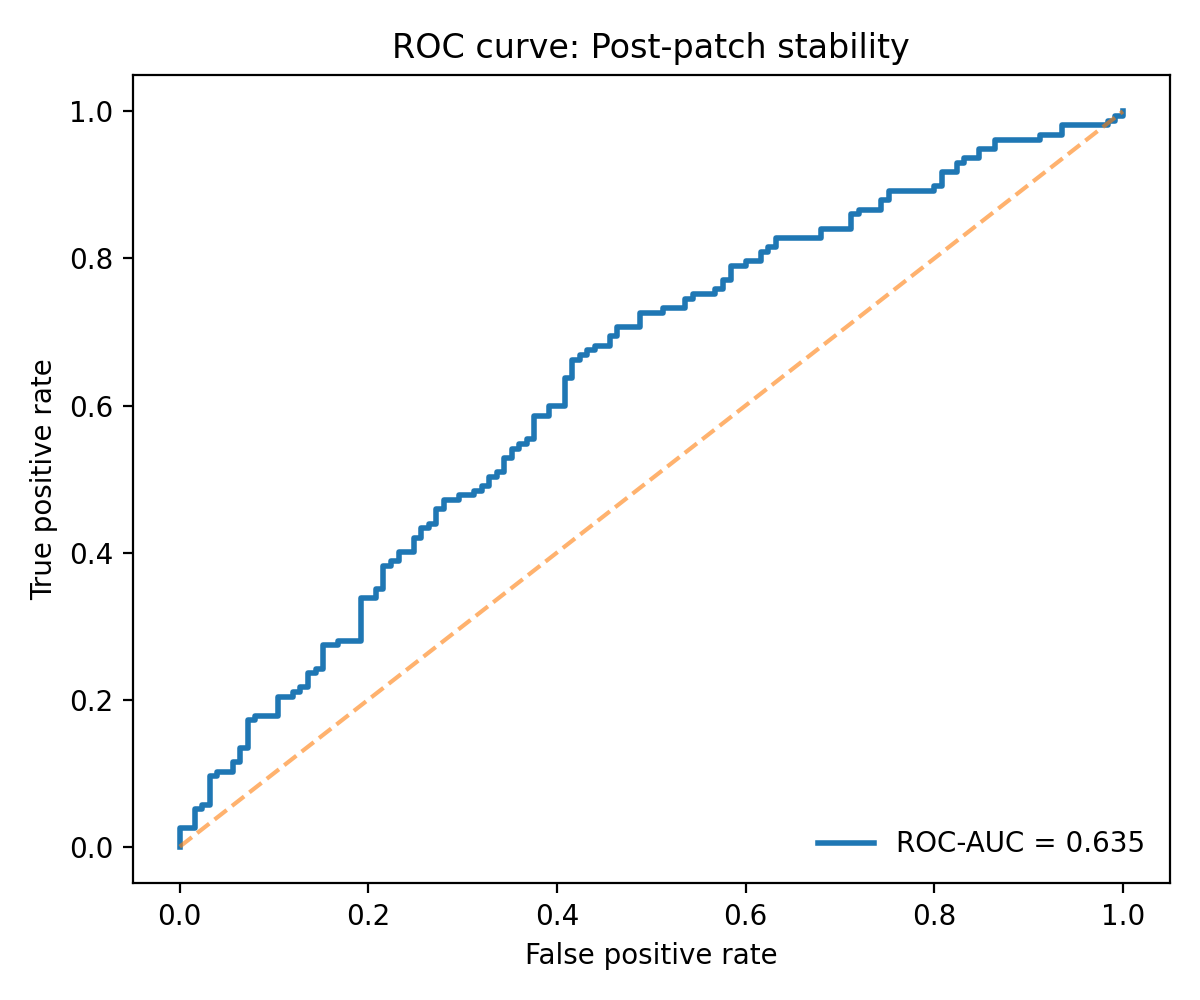

In [7]:
display(Image(filename=str(FIG_DIR / "ml_confusion_matrix_stability.png")))
display(Image(filename=str(FIG_DIR / "ml_roc_curve_stability.png")))


### High-performance task diagnostics


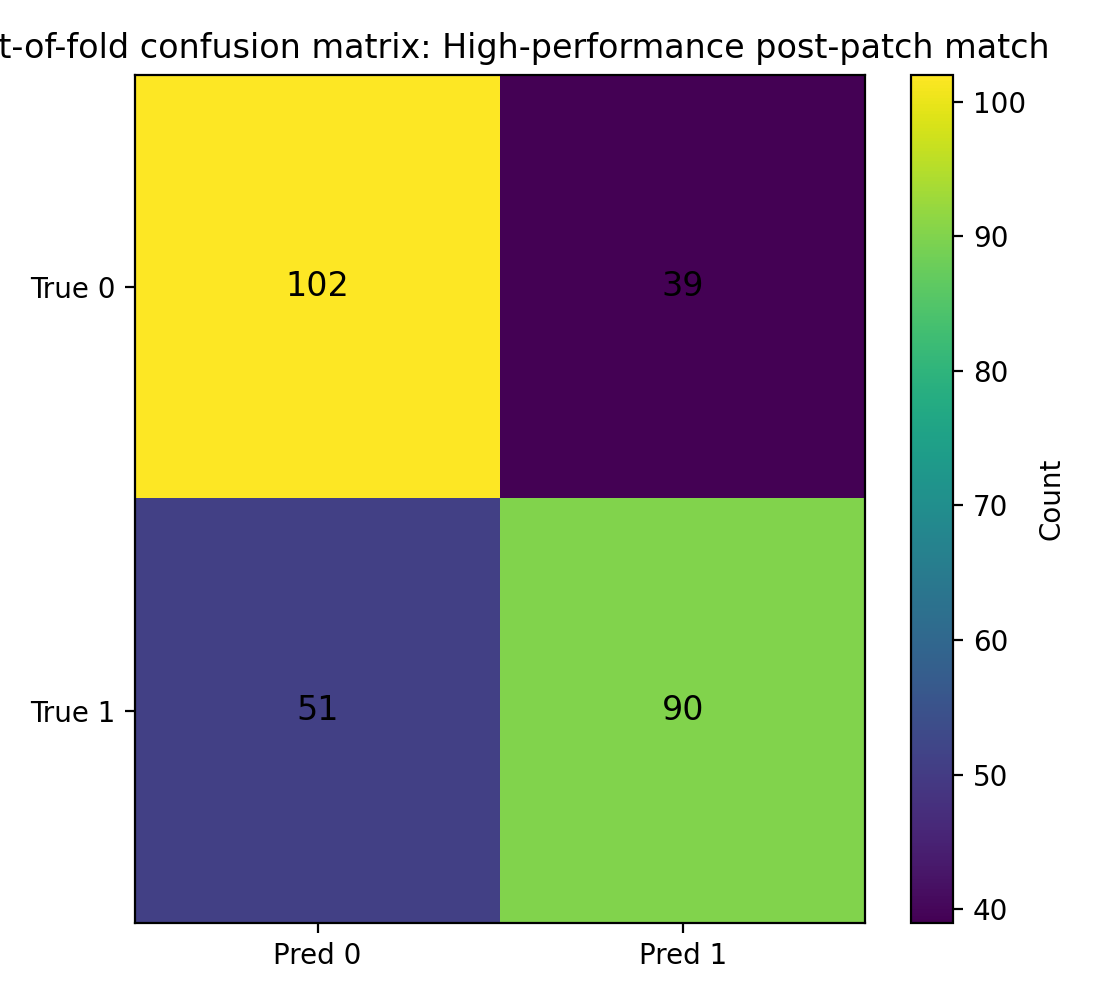

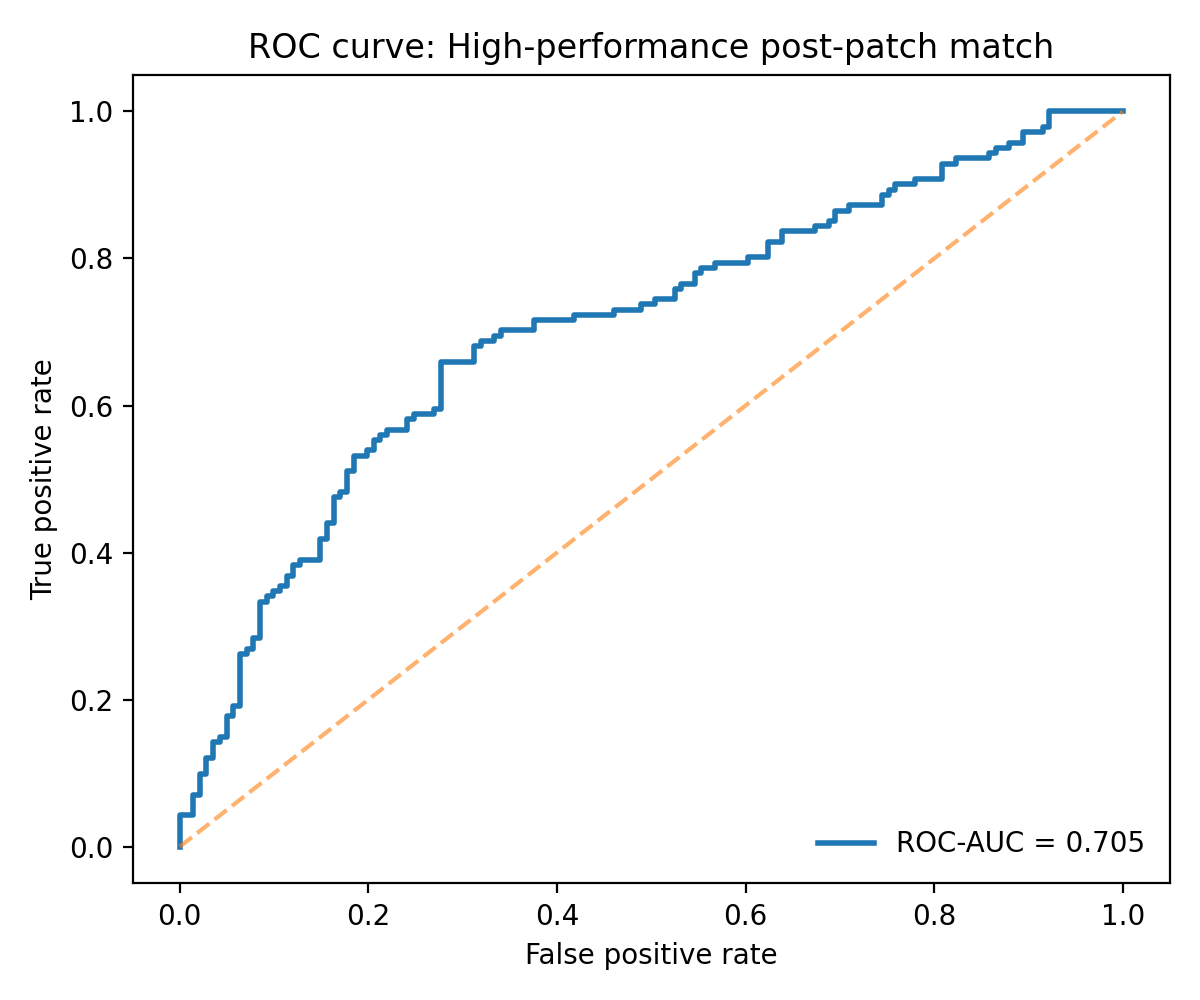

In [8]:
display(Image(filename=str(FIG_DIR / "ml_confusion_matrix_high_perf.png")))
display(Image(filename=str(FIG_DIR / "ml_roc_curve_high_perf.png")))


ROC-AUC is useful here because it reflects ranking quality, not just a single decision threshold.


## Feature importance


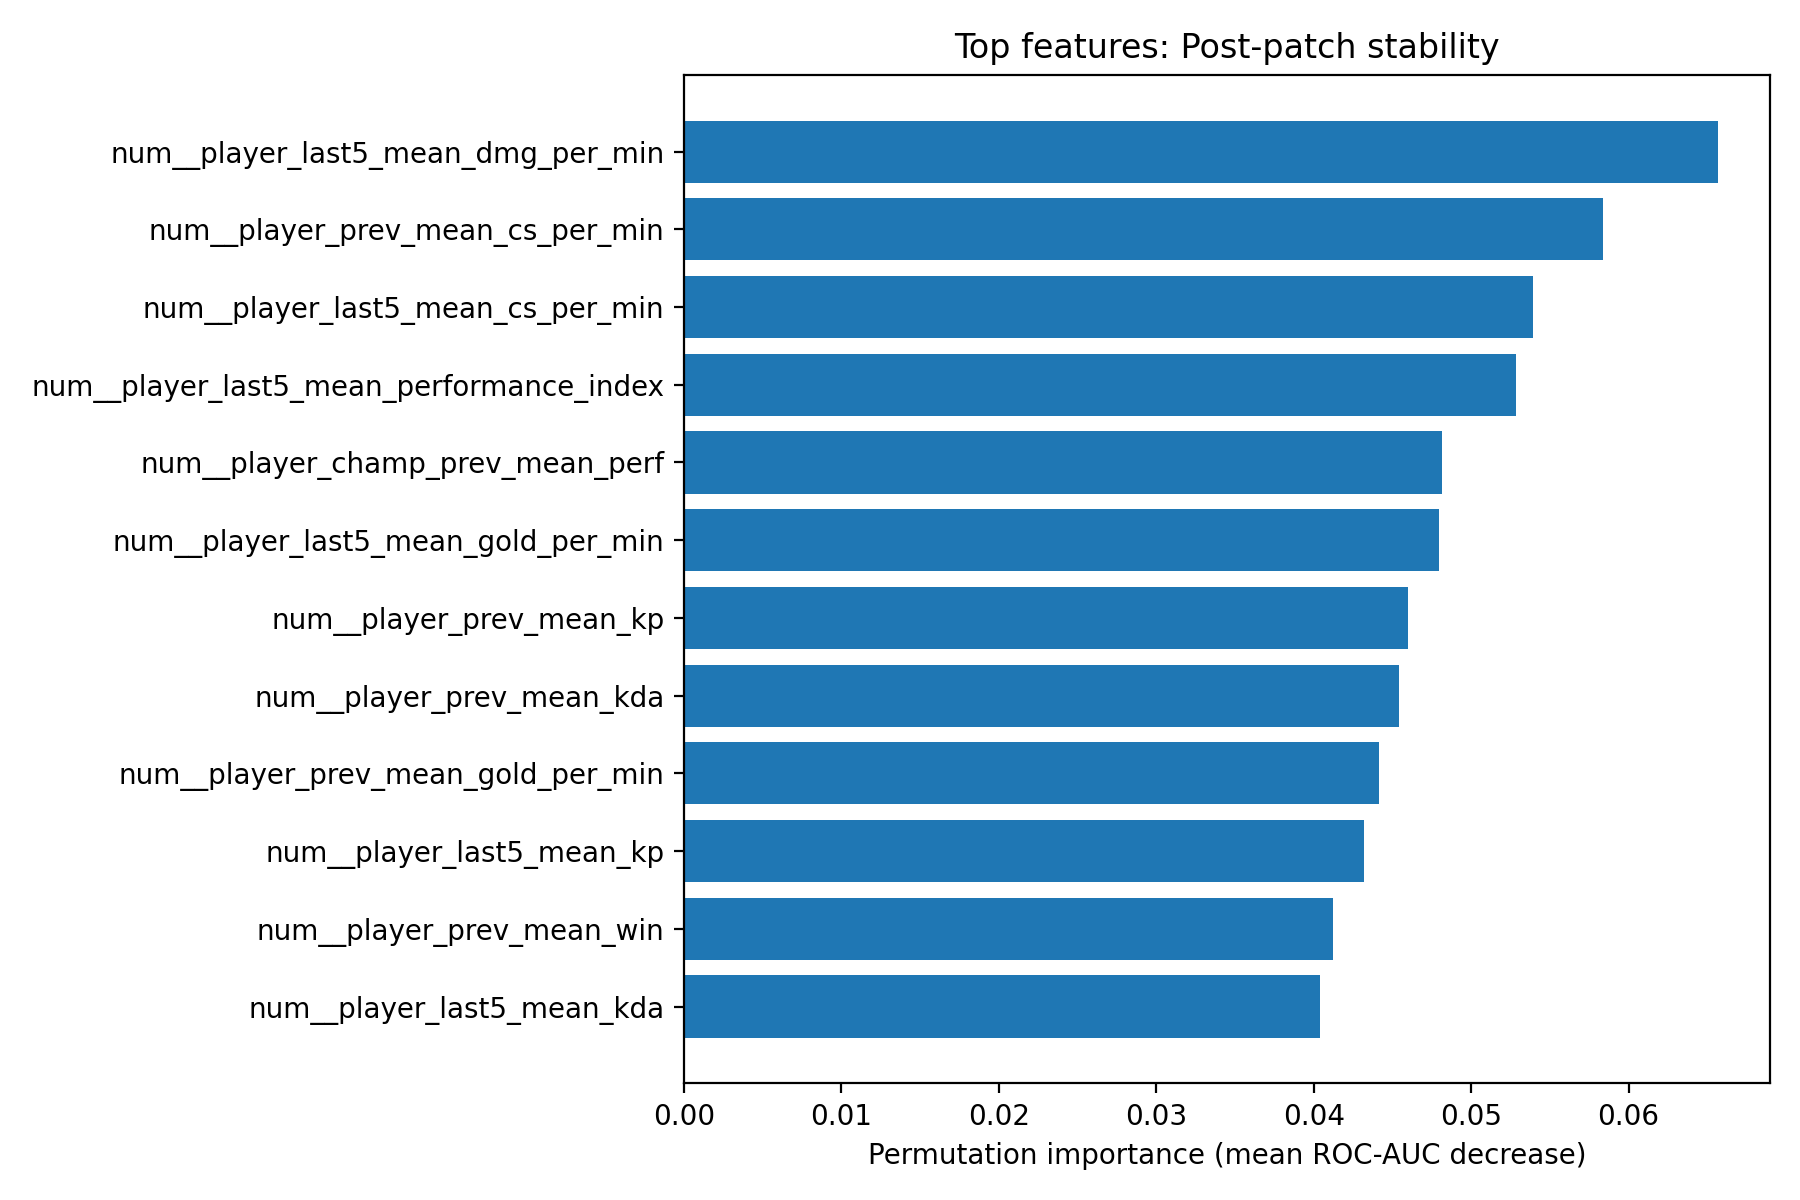

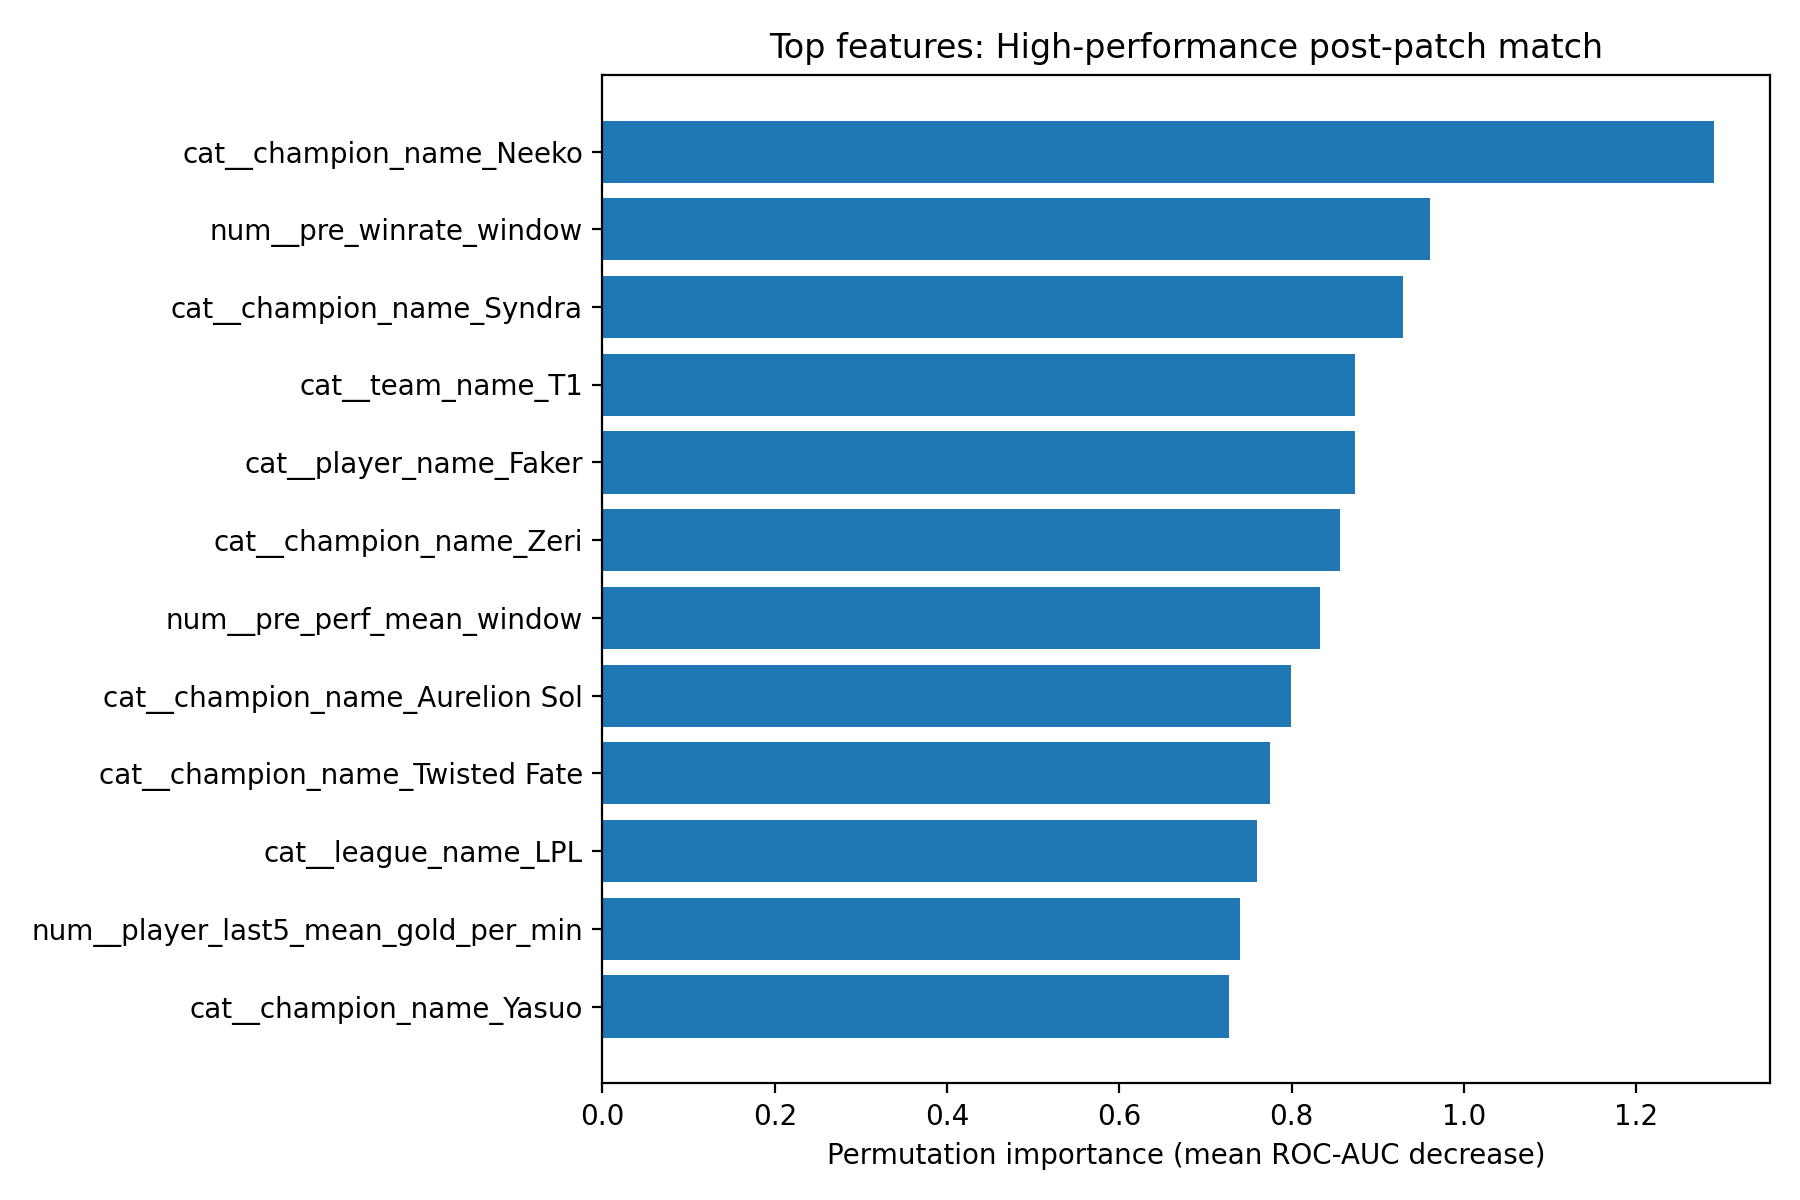

In [9]:
display(Image(filename=str(FIG_DIR / "ml_top_features_stability.png")))
display(Image(filename=str(FIG_DIR / "ml_top_features_high_perf.png")))


In [10]:
top_stability = (
    importance[importance["target"] == "stable_match"]
    .sort_values("importance_mean", ascending=False)
    .head(10)
)
top_high = (
    importance[importance["target"] == "high_performance_match"]
    .sort_values("importance_mean", ascending=False)
    .head(10)
)

display(Markdown("### Top encoded features for stability"))
display(top_stability.round(4))
display(Markdown("### Top encoded features for high-performance matches"))
display(top_high.round(4))


### Top encoded features for stability

,feature,importance_mean,importance_std,target,target_label,best_model
0,num__player_last5_mean_dmg_per_min,0.0657,0.0,stable_match,Post-patch stability,random_forest
1,num__player_prev_mean_cs_per_min,0.0583,0.0,stable_match,Post-patch stability,random_forest
2,num__player_last5_mean_cs_per_min,0.0539,0.0,stable_match,Post-patch stability,random_forest
3,num__player_last5_mean_performance_index,0.0529,0.0,stable_match,Post-patch stability,random_forest
4,num__player_champ_prev_mean_perf,0.0482,0.0,stable_match,Post-patch stability,random_forest
5,num__player_last5_mean_gold_per_min,0.0479,0.0,stable_match,Post-patch stability,random_forest
6,num__player_prev_mean_kp,0.0460,0.0,stable_match,Post-patch stability,random_forest
7,num__player_prev_mean_kda,0.0454,0.0,stable_match,Post-patch stability,random_forest
8,num__player_prev_mean_gold_per_min,0.0442,0.0,stable_match,Post-patch stability,random_forest
9,num__player_last5_mean_kp,0.0432,0.0,stable_match,Post-patch stability,random_forest


### Top encoded features for high-performance matches

,feature,importance_mean,importance_std,target,target_label,best_model
77,cat__champion_name_Neeko,1.2906,0.0,high_performance_match,High-performance post-patch match,logistic_regression
78,num__pre_winrate_window,0.9607,0.0,high_performance_match,High-performance post-patch match,logistic_regression
79,cat__champion_name_Syndra,0.9291,0.0,high_performance_match,High-performance post-patch match,logistic_regression
80,cat__team_name_T1,0.8733,0.0,high_performance_match,High-performance post-patch match,logistic_regression
81,cat__player_name_Faker,0.8733,0.0,high_performance_match,High-performance post-patch match,logistic_regression
82,cat__champion_name_Zeri,0.8562,0.0,high_performance_match,High-performance post-patch match,logistic_regression
83,num__pre_perf_mean_window,0.8329,0.0,high_performance_match,High-performance post-patch match,logistic_regression
84,cat__champion_name_Aurelion Sol,0.7990,0.0,high_performance_match,High-performance post-patch match,logistic_regression
85,cat__champion_name_Twisted Fate,0.7743,0.0,high_performance_match,High-performance post-patch match,logistic_regression
86,cat__league_name_LPL,0.7593,0.0,high_performance_match,High-performance post-patch match,logistic_regression


## Holdout evaluation on the final patch

In addition to shuffled cross-validation, the best model for each task was trained on earlier patches and evaluated on patch **14.16** only.
This is a more realistic test of generalization to a future patch.


In [11]:
display(holdout.round(4))


,target,target_label,holdout_patch,model,n_train,n_test,test_positive_rate,accuracy,balanced_accuracy,f1,roc_auc
0,stable_match,Post-patch stability,14.16,random_forest,197,85,0.7294,0.6118,0.5288,0.7273,0.5575
1,high_performance_match,High-performance post-patch match,14.16,logistic_regression,197,85,0.5529,0.5059,0.4801,0.6182,0.5370


**Interpretation:** holdout performance is weaker than shuffled cross-validation, which is expected. Predicting behavior in a future patch is harder than predicting behavior in randomly mixed folds.


## Best-model summary


In [12]:
best_summary = (
    comparison.sort_values(["target", "cv_roc_auc_mean"], ascending=[True, False])
    .groupby("target")
    .head(1)
    [["target_label", "model", "cv_accuracy_mean", "cv_balanced_accuracy_mean", "cv_f1_mean", "cv_roc_auc_mean"]]
    .round(3)
)
display(best_summary)


,target_label,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
2,High-performance post-patch match,logistic_regression,0.681,0.681,0.668,0.704
0,Post-patch stability,random_forest,0.624,0.612,0.679,0.639


## Milestone 2 conclusion

The machine learning results show that post-patch outcomes are **somewhat predictable**, but far from perfectly predictable.

- For the **stability** target, the best model achieved moderate performance.
- For the **high-performance** target, the best model performed somewhat better.
- The drop from cross-validation to holdout evaluation shows that future patch behavior remains difficult to predict.

This is useful for the project because it turns the original descriptive question into a predictive one while still keeping the interpretation honest.


## Reproducibility

The files used in this notebook are generated by:

```bash
python scripts/run_milestone_analysis.py
python scripts/run_ml_analysis.py
```
